# Building a Simple Polynomial Accelerator

In this notebook, we will build a simple **polynomial function** accelerator to illustrate the basic concepts of PySilicon.
In going through the example, you will learn to:

- Define `DataSchema` classes describing data in and out of the accelerator
- Create python objects following the DatSchema formats
- Generate a simple Golden model in python describing the ideal behavior of the Vitis IP
- Generated test vectors from the Golden models
- Passing the test vectors to a Vitis HLS testbench
- Auto-generating header files from the DataSchema 

Right now, PySilicon only provides the DataSchema class.  Later, I will modify this demo to show how the IP as a PySilicon hardware object when that is developed.

In [39]:
import numpy as np

In [ ]:
for module in modules:
    print(f"Reloading module: {module.__name__}")
    importlib.reload(module)

from pysilicon.hw.dataschema import IntField, FloatField, DataList, DataArray, EnumField
from pysilicon.build.streamutils import copy_streamutils
from pysilicon.build.build import CodeGenConfig


Reloading module: pysilicon
Reloading module: pysilicon.hw
Reloading module: pysilicon.hw.dataschema
Reloading module: pysilicon.codegen.streamutils
Reloading module: pysilicon.codegen.build


## Polynomial Accelerator Protocol

We will develop a polynomial accelerator that uses the following protocol:

- The client sends a `PolyCmdHeader` with coefficients and execution metadata.
- The client then streams `SampleDataIn` values (`x`).
- The accelerator can reply with `PolyRespHeader` early (before all inputs finish) so the host can correlate timing and transaction state.
- The accelerator streams `SampleDataOut` values (`y`) as results become available.
- The accelerator ends with `PolyRespFooter`, which includes final counters and error status.


## Defining the Data Formats

The first task in defining the accelerator is to provide the data structures representing the input and output to the module.  In PySilicon these data sturctures are specified by **DataSchema** classes.  We will begin with the defintiion of the control messages, namely `PolyCmdHeader`, `PolyRespHeader` and `PolyRespFooter`.  You can see that these are defined as sub-classes of `DataList` since they are simple list of items.

Observe that the  `PolyCmdHeader` sends a transcation ID, `tx_id`, that is echo-ed in the `PolyRespHeader`.  This ensures that the response is for a particular job and is useful in case of loss of packets or synchronization. 

In [41]:
include_dir = 'include'
cg_cfg = CodeGenConfig(
    #util_dir=include_dir
)

word_bw_supported = [32, 64]

In [42]:
from enum import IntEnum
class PolyError(IntEnum):
    NO_ERROR = 0
    WRONG_NSAMP = 1


PolyErrorField = EnumField.specialize(
    enum_type = PolyError,
    include_dir=include_dir)

class CoeffArray(DataArray):
    ncoeffs = 4
    element_type = FloatField
    static = True
    max_shape = (ncoeffs,)
    include_dir=include_dir


class PolyCmdHdr(DataList):
    elements = {
        'tx_id' : {
            'schema' : IntField.specialize(16, signed=False),
            'description' : 'Transaction ID'
        },
        'coeffs' : {
            'schema' : CoeffArray,
            'description' : 'Polynomial coefficients'
        },
        'nsamp' : {
            'schema' : IntField.specialize(16, signed=False),
            'description' : 'Number of samples'
        }
    }
    include_dir=include_dir

class PolyRespHdr(DataList):
    elements = {
        'tx_id' : {
            'schema' : IntField.specialize(16, signed=False),
            'description' : 'Echo of the Transaction ID sent in the command'
        }
    }
    include_dir=include_dir

class PolyRespFtr(DataList):
    elements = {
        'nsamp_read' : {
            'schema' : IntField.specialize(16, signed=False),
            'description' : 'Number of samples actually read and returned in the response'
        },
        'error' : {
            'schema' : PolyErrorField,
            'description' : 'Error code indicating success or type of failure'
        }
    }
    include_dir=include_dir

classes = [ PolyErrorField, CoeffArray, PolyCmdHdr, PolyRespHdr, PolyRespFtr ]
for c in classes:
    p = c.gen_include(cfg=cg_cfg, word_bw_supported=word_bw_supported)
    print(f"Generated header for {c.__name__} at: {p}")


Generated header for PolyErrorEnumField at: c:\Users\sdran\Documents\repos\pysilicon\examples\poly\include\poly_error.h
Generated header for CoeffArray at: c:\Users\sdran\Documents\repos\pysilicon\examples\poly\include\coeff_array.h
Generated header for PolyCmdHdr at: c:\Users\sdran\Documents\repos\pysilicon\examples\poly\include\poly_cmd_hdr.h
Generated header for PolyRespHdr at: c:\Users\sdran\Documents\repos\pysilicon\examples\poly\include\poly_resp_hdr.h
Generated header for PolyRespFtr at: c:\Users\sdran\Documents\repos\pysilicon\examples\poly\include\poly_resp_ftr.h


Next, we define the sample data arrays for the input and output.  These structures use the `DataArray` class.  The `static = False` specifies that the data arrays are variable length.

In [43]:
max_nsamp = 128

class SampDataIn(DataArray):
    element_type = FloatField
    static = False
    max_shape = (max_nsamp,)
    include_dir=include_dir

class SampDataOut(DataArray):
    element_type = FloatField
    static = False
    max_shape = (max_nsamp,)
    include_dir=include_dir

classes = [ SampDataIn, SampDataOut ]
for c in classes:
    p = c.gen_include(cfg=cg_cfg, word_bw_supported=word_bw_supported)
    print(f"Generated header for {c.__name__} at: {p}")

Generated header for SampDataIn at: c:\Users\sdran\Documents\repos\pysilicon\examples\poly\include\samp_data_in.h
Generated header for SampDataOut at: c:\Users\sdran\Documents\repos\pysilicon\examples\poly\include\samp_data_out.h


In [44]:
# Maximum number of samples that can be processed in one command/response transaction.
max_nsamp = 128

class SampleDataIn(DataArray):
    """  Input samples  """
    def __init__(self, name=None):
        super().__init__(
            name=name,
            element_type=FloatField(name="x", bitwidth=32),
            max_shape=(max_nsamp,),
            static=False,
            description="Input samples to be processed by the polynomial"
        )

class SampleDataOut(DataArray):
    """  Output samples  """
    def __init__(self, name=None):
        super().__init__(
            name=name,
            element_type=FloatField(name="y", bitwidth=32),
            max_shape=(max_nsamp,),
            static=False,
            description="Input samples to be processed by the polynomial"
        )

## 3. Create Test Data with a Python Golden Model

Now we instantiate and populate sample command and payload objects.  This mirrors what processing system would send to the polynomial accelerator.  In this simple example, we set the coefficients and send data value `x` spaced uniformly from 0 to 1.

In [46]:
# Coefficients
coeffs = CoeffArray()
coeffs.val = np.array([1.0, -2.0, -3.0, 4.0], dtype=np.float32)

# Command header
nsamp = 100
cmd_hdr = PolyCmdHdr()
cmd_hdr.txn_id = 42
cmd_hdr.coeffs = coeffs.val

samp_in = SampleDataIn()
samp_in.val = np.linspace(0, 1, nsamp, dtype=np.float32)



TypeError: DataField.__init__() got an unexpected keyword argument 'name'

Next, we create a *Golden model* in python of the expected behavior on the transaction.  Importantly, the Golden model should take the exact same data structures as the intended hardware.

In [32]:
def polynomial_eval(
        cmd_hdr : PolyCmdHeader,
        samp_in : SampleDataIn
) -> tuple[PolyRespHeader, SampleDataOut, PolyRespFooter]:
    """
    Python model for the polynomial evaluation accelerator. 
    
    Parameters
    ----------
    cmd_hdr : PolyCmdHeader
        Command header containing transaction ID, coefficients, and number of samples.
    samp_in : SampleDataIn
        Input samples to be processed by the polynomial.

    Returns
    -------
    resp_hdr : PolyRespHeader
        Response header containing the echoed transaction ID.
    samp_data_out : SampleDataOut
        Output samples after polynomial evaluation.
    resp_ftr : PolyRespFooter
        Response footer containing the number of data read and error code.
    """
    # Compute the response header which is just the echo of the transaction ID
    resp_hdr = PolyRespHeader(name="poly_resp_header")
    resp_hdr.txn_id = cmd_hdr.txn_id

    # Compute the output sample data
    coeffs = cmd_hdr.coeffs
    nsamp = len(samp_in.val)
    p = np.ones(nsamp, dtype=np.float32) 
    x = samp_in.val
    y = np.zeros(nsamp, dtype=np.float32)  # Start with the leading coefficient
    for coeff in coeffs:
        y += coeff*p
        p *= x  # Update p for the next term

    samp_data_out = SampleDataOut(name="sample_data_out")
    samp_data_out.val = y

    # Compute the response footer
    resp_ftr = PolyRespFooter(name="poly_resp_footer")
    resp_ftr.ndata_read = len(samp_in.val)

    if len(samp_in.val) != cmd_hdr.nsamp:
        resp_ftr.err_code = PolyError.WRONG_NSAMP
    else:
        resp_ftr.err_code = PolyError.NO_ERROR
    
    return resp_hdr, samp_data_out, resp_ftr



Now we run the Golden model and plot the results

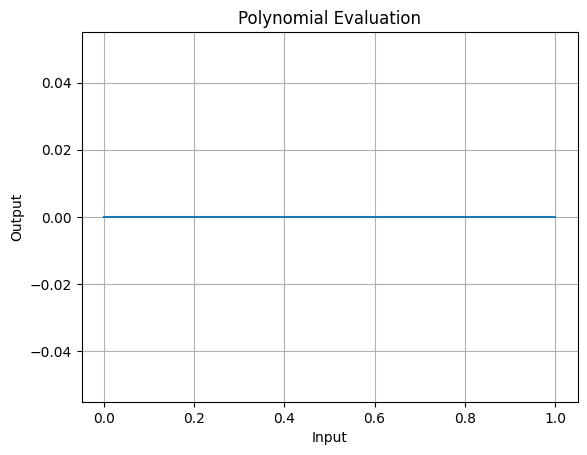

In [33]:
resp_hdr, samp_out, resp_ftr = polynomial_eval(cmd_hdr, samp_in)

x = samp_in.val
y = samp_out.val

import matplotlib.pyplot as plt
plt.plot(x, y)
plt.xlabel("Input")
plt.ylabel("Output")
plt.title("Polynomial Evaluation")
plt.grid()
plt.show()



## Generate Vitis Include Files


Now that the Golden model is built, we start with the Vitis HLS implementation.  We begin by generating the include files for all the data structures.  Instead of manually creating C++ data structures to match the python, PySilicon can auto-generate these files.  The files will also include valuable streaming utilties for reading and writing the data from streams and memory.

The parameter `word_bw_supported` indicates the word bitwidths that it will auto-generate the serialization and deserialization functions for.


In [37]:
from pathlib import Path
out_dir = Path.cwd()

# Copy the streamutils header
copy_streamutils(dst_path=out_dir)


cmd_hdr = PolyCmdHeader(name="poly_cmd_header")

# Bit widths to generate 
word_bw_supported = [32,64]

# Data schemas to generate includes for
schemas = [err_field, coeffs, cmd_hdr, samp_in, samp_out, resp_hdr, resp_ftr]

for schema in schemas:
    include_path = schema.gen_include(include_dir=str(out_dir), word_bw_supported=word_bw_supported)
    print("generated:", include_path)

generated: c:\Users\sdran\Documents\repos\pysilicon\examples\poly\poly_error.h
generated: c:\Users\sdran\Documents\repos\pysilicon\examples\poly\coeffs.h
generated: c:\Users\sdran\Documents\repos\pysilicon\examples\poly\poly_cmd_header.h
generated: c:\Users\sdran\Documents\repos\pysilicon\examples\poly\sample_data_in.h
generated: c:\Users\sdran\Documents\repos\pysilicon\examples\poly\sample_data_out.h
generated: c:\Users\sdran\Documents\repos\pysilicon\examples\poly\poly_resp_header.h
generated: c:\Users\sdran\Documents\repos\pysilicon\examples\poly\poly_resp_footer.h


## Generating the Test Vectors

We next generate the input test vectors to be sent to the test bench.  This is done most easily with the `write_uint32_file()` method that writes the contents of the data to a file, serializing the data into `uint32` words.

In [35]:
cmd_hdr.write_uint32_file("cmd_hdr_data.bin")
_ = samp_in.write_uint32_file("samp_in_data.bin", nwrite=cmd_hdr.nsamp)

## Running the Testbench

We can run the testbench and kernel file

In [36]:
from subprocess import CalledProcessError
from pysilicon.xilinxutils.toolchain import run_vitis_hls

try:
    result = run_vitis_hls(
        tcl_script="run.tcl",
        capture_output=True,
    )
    print("Vitis HLS completed successfully")
    if result.stdout:
        print("--- stdout ---")
        print(result.stdout)
    if result.stderr:
        print("--- stderr ---")
        print(result.stderr)
except CalledProcessError as exc:
    print(f"Vitis HLS failed with exit code {exc.returncode}")
    if exc.stdout:
        print("--- stdout ---")
        print(exc.stdout)
    if exc.stderr:
        print("--- stderr ---")
        print(exc.stderr)
    raise

Vitis HLS failed with exit code 1
--- stdout ---

****** vitis-run v2025.1 (64-bit)
  **** SW Build 6137779 on 2025-05-21-18:10:16
  **** Start of session at: Sat Mar 21 20:35:26 2026
    ** Copyright 1986-2022 Xilinx, Inc. All Rights Reserved.
    ** Copyright 2022-2025 Advanced Micro Devices, Inc. All Rights Reserved.

  **** HLS Build v2025.1 6135595

Sourcing Tcl script 'c:/Users/sdran/Documents/repos/pysilicon/examples/poly/run.tcl'

INFO: [HLS 200-1510] Running: open_project -reset pysilicon_poly_proj 


Resolution: For help on HLS 200-2182 see docs.xilinx.com/access/sources/dita/topic?Doc_Version=2025.1%20English&url=ug1448-hls-guidance&resourceid=200-2182.html

INFO: [HLS 200-10] Opening and resetting solution 'C:/Users/sdran/Documents/repos/pysilicon/examples/poly/pysilicon_poly_proj'.

INFO: [HLS 200-1510] Running: set_top poly 

INFO: [HLS 200-1510] Running: add_files poly.cpp 

INFO: [HLS 200-10] Adding design file 'poly.cpp' to the project

INFO: [HLS 200-1510] Running: ad

CalledProcessError: Command 'cmd.exe /c "call "C:\Xilinx\2025.1\Vitis\bin\vitis-run.bat" "--mode" "hls" "--tcl" "run.tcl""' returned non-zero exit status 1.